# Fundamental analysis of US Stock Market
In this notebook I carry out fundamental analysis of companies from the [S&P 500 Index](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies) using their annual financial reporting as made available by Yahoo-Finance with the help of the [yfinance](https://pypi.org/project/yfinance/) library. Specifically I look at:
* the market capitalization of listed companies that are members of the S&P 500
* their effective tax rate
* their return on invested capital (ROIC), and its variant called recurring return on invested capital (Recurring ROIC)
* their return on equity
* their cost of equity
* their after tax cost of debt
* their weighted average cost of capital (WACC)
* their enterprise value added (EVA)
* their market value added (MVA)

I calculated these metrics as follows:
$$\text{Effective tax rate} = \frac{\text{Tax Provision}}{\text{Pretax Income}}$$
$$\text{NOPAT} = \text{Net Income} + \text{Net Interest} \times (1 - \text{Effective tax rate})$$
$$\text{Recurring NOPAT} = \text{NOPAT} + \text{Non recurring items} \times (1 - \text{Effective tax rate})$$
$$\text{Invested Capital} = \text{Total Equity} + \text{Net Debt}$$
$$\text{ROIC} = \frac{\text{NOPAT}}{\text{Invested Capital}}$$
$$\text{Recurring ROIC} = \frac{\text{Recurring NOPAT}}{\text{Invested Capital}}$$
$$\text{After Tax Cost of Debt} = \frac{\text{Interest Expense Non Operating}}{\text{Total Debt}} \times (1 - \text{Effective tax rate})$$
$$\text{Cost of Equity} = \text{1-year risk-free rate} + \text{Company stock's } \beta \times \text{Expected market return}$$
$$\text{ROE} = \frac{\text{Net Income}}{\text{Total Equity}}$$
$$\text{EVA} = (\text{ROIC} - \text{WACC}) \times \text{Invested Capital}$$
$$\text{MVA} = \text{Market Value of Equity} + \text{Market Value of Debt} - \text{Invested Capital}$$

Important notes:
* I use the average `Invested Capital` of the reporting year and the year before: 1) in the denominator when calculating `ROIC` and `Recurring ROIC` and 2) when calculating `EVA`.
* I use the average `Total Debt` of the reporting year and the year before in the denominator when calculating `After Tax Cost of Debt`.
* I use the average `Total Equity` of the reporting year and the year before in the denominator when calculating `ROE`.
* As the 1-Year risk-free rate I use Market Yield on U.S. Treasury Securities at 1-Year (it is a par yield).
* As `Expected market return` over the risk-free rate I use the industry practice of taking it to be 5%.
* For `Cost of Debt`, I  calculate &beta; using 5-Year Monthly volatility of a given stock and its correlation with the S&P 500 index.

All amounts are represented in either Billions of USD or as percentage points.

In [1]:
# Uncomment if running in Google Colaboratory, otherwise the import of the curves module in the cell below will fail
#!git clone -l -s https://github.com/ilchen/US_Economic_Data_Analysis.git cloned-repo
#%cd cloned-repo

# Install the latest version of pandas-datareader and yfinance
# !pip install pandas-datareader -U
# !pip install yfinance -U

In [87]:
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import yfinance as yfin

from datetime import date

from stock_market import metrics

In [29]:
# Human readable column names for DataFrames
MKT_CAP_TOP10_SP500 = 'Top-10 S&P 500 companies by market capitalization'
EXCESS_RETURN_SP500 = 'Excess Annual Return of S&P 500 over 1-year Riskless rate'

# Y axis labels for graphs
LEFT_Y_AXIS_LABEL = 'Billions of USD'
RIGHT_Y_AXIS_LABEL = '% of GDP'

TTM_SUFFIX = ' (ttm)'
MRQ_SUFFIX = ' (mrq)'

In [3]:
start = date(2020, 1, 1)
sp500_hist_comps = metrics.USStockMarketMetrics.get_sp500_historical_components(start)
_, additional_share_classes = metrics.USStockMarketMetrics.get_sp500_components()
sp500_hist_shares_outs = metrics.USStockMarketMetrics.get_sp500_historical_shares_outstanding()
sp500_metrics = metrics.USStockMarketMetrics(sp500_hist_comps, additional_share_classes, start=start,
                                             hist_shares_outs=sp500_hist_shares_outs)

[**                     5%                       ]  33 of 612 completed$CTLT: possibly delisted; no timezone found
[***                    6%                       ]  34 of 612 completed$ABMD: possibly delisted; no timezone found
[******                12%                       ]  76 of 612 completed$XLNX: possibly delisted; no timezone found
[*******               14%                       ]  84 of 612 completed$DISH: possibly delisted; no timezone found
[*******               14%                       ]  85 of 612 completed$NLSN: possibly delisted; no timezone found
[*******               14%                       ]  86 of 612 completed$K: possibly delisted; no price data found  (1d 2020-01-01 -> 2026-04-19) (Yahoo error = "No data found, symbol may be delisted")
[*********             19%                       ]  114 of 612 completed$MRO: possibly delisted; no timezone found
[*********             19%                       ]  115 of 612 completed$HBI: possibly delisted; no price dat

Correcting the number of shares outstanding for BF-B from 458703629 to 290262390
Correcting the number of shares outstanding for TSN from 352078966 to 282069961
Correcting the number of shares outstanding for BIO from 27002387 to 21924404
Correcting the number of shares outstanding for FOX from 466853928 to 224702222
Correcting the number of shares outstanding for GOOGL from 12097000000 to 5822000000
	Extra correction for the number of shares outstanding for GOOGL from 2020-01-02 to 2025-01-28
	Extra correction for the number of shares outstanding for SBNY from 2020-01-02 to 2023-01-31
Correcting the number of shares outstanding for AOS from 138289918 to 112376652
Correcting the number of shares outstanding for NWS from 548711015 to 182947903
Correcting the number of shares outstanding for COIN from 269657615 to 223041278
Correcting the number of shares outstanding for FOXA from 425396078 to 200693856
Correcting the number of shares outstanding for SATS from 288875859 to 157527391
Corr

[*********************100%***********************]  1 of 1 completed


### Fundamental analysis of Top-10 by current market capitalization
I first look at the 10 largest compnaies by market capitalizaiton as of the latest trading day.

In [4]:
top10_today = sp500_metrics.get_top_n_capitalization_companies_for_day(10, merge_additional_share_classes=True)
pd.options.display.float_format = (lambda x: '{:.2%}'.format(x) if abs(x) < 5 else '${:,.2f}bn'.format(x/1e9) if not pd.isna(x) else '<NA>')
pd.options.display.max_rows = 80

In [7]:
top10_today

,Capitalization,Market share (%)
NVDA,"$4,901.83bn",7.66%
AAPL,"$3,971.82bn",6.20%
GOOGL,"$3,834.92bn",5.99%
MSFT,"$3,142.34bn",4.91%
AMZN,"$2,694.59bn",4.21%
AVGO,"$1,927.52bn",3.01%
META,"$1,741.73bn",2.72%
TSLA,"$1,503.30bn",2.35%
WMT,"$1,016.48bn",1.59%
JPM,$836.86bn,1.31%


In [18]:
tickers = list(top10_today.index)
for additional_share_class, main_share_class in sp500_metrics.additional_share_classes.items():
    if additional_share_class in tickers and main_share_class not in tickers:
        tickers.append(main_share_class)
    elif main_share_class in tickers and additional_share_class not in tickers:
        tickers.append(additional_share_class)

In [26]:
top10_capitalization = sp500_metrics.get_capitalization_for_companies(tickers, 'W').iloc[:,1:]
names = sp500_metrics.tickers_to_display_names(tickers)
ticker_to_name = dict(zip(tickers, names))

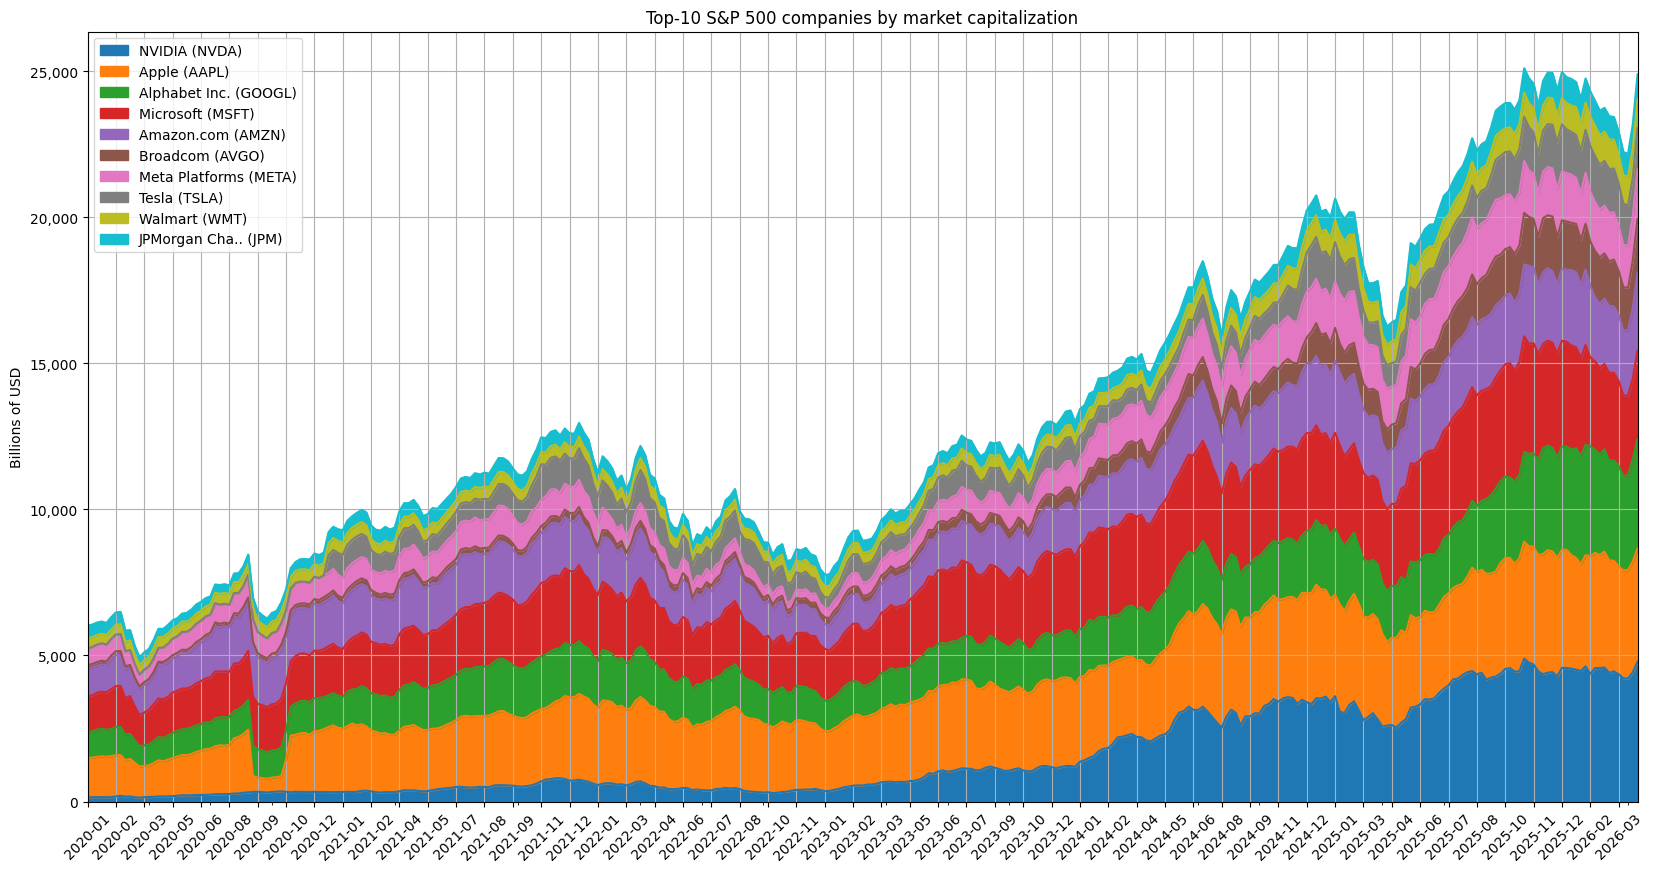

In [37]:
top10_weekly = top10_capitalization.loc[:, top10_capitalization.iloc[-1].sort_values(ascending=False).index]
ax = top10_weekly.plot.area(figsize=(20,10), grid=True, title=MKT_CAP_TOP10_SP500,
                            xticks=top10_weekly.index[::6], xlabel='', rot=45,
                            ylabel=LEFT_Y_AXIS_LABEL)
ax.legend(ax.collections, top10_weekly.columns.map(lambda ticker: ticker_to_name[ticker] + f' ({ticker})'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: '{:,.0f}'.format(x/1e9)))
_ = ax.set_xticklabels(list(map('{:%Y-%m}'.format, top10_weekly.index[::6])))

In [85]:
fa_metrics = sp500_metrics.calculate_financial_metrics(list(top10_today.index)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

#### Fundamentals sorted by the current market value added (MVA)

In [86]:
latest_mva = fa_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_metrics.loc[sorted_symbols].iloc[:,:10]

Effective tax rate    ROIC Recurring ROIC     ROE Recurring ROE  \
symbol year                                                                    
NVDA   2023               0.00%  23.98%         16.97%  19.76%        13.64%   
       2024              12.00%  79.89%         79.89%  91.46%        91.46%   
       2025              13.26% 117.05%        117.05% 119.18%       119.18%   
       2026              15.12% 102.53%        102.53% 101.49%       101.49%   
AAPL   2022              16.20%  69.52%         69.52% 196.96%       196.96%   
       2023              14.72%  69.12%         69.12% 171.95%       171.95%   
       2024              24.09%  67.70%         67.70% 157.41%       157.41%   
       2025              15.61%  82.94%         82.94% 171.42%       171.42%   
MSFT   2022              13.11%  36.82%         36.97%  43.68%        43.85%   
       2023              18.98%  35.12%         35.12%  38.82%        38.82%   
       2024              18.23%  34.78%         34.61%  37.13%        36.94%   
       2025              17.63%  31.54%         31.43%  33.28%        33.16%   
AMZN   2022              18.59%  -0.50%         -8.81%  -1.86%       -10.93%   
       2023              18.59%  19.08%         19.57%  17.49%        17.98%   
       2024              18.59%  27.41%         26.74%  24.29%        23.68%   
       2025              18.59%  24.48%         28.32%  22.29%        25.86%   
AVGO   2022               7.55%  26.33%         25.91%  50.62%        49.70%   
       2023               6.72%  31.59%         31.15%  60.31%        59.38%   
       2024              37.80%   9.56%          8.46%  12.86%        10.77%   
       2025               0.00%  20.57%         20.09%  31.05%        30.23%   
META   2022              19.50%  19.09%         19.03%  18.45%        18.40%   
       2023              17.56%  31.12%         30.88%  28.04%        27.82%   
       2024              11.75%  41.88%         41.47%  37.14%        36.78%   
       2025              29.64%  29.92%         30.04%  30.24%        30.36%   
TSLA   2022               8.25%  40.26%         39.75%  27.42%        27.06%   
       2023               0.00%  36.27%         36.27%  27.39%        27.39%   
       2024              20.43%  12.63%         11.71%  10.39%         9.59%   
       2025              26.96%   5.78%          5.26%   4.85%         4.39%   
GOOGL  2022              15.92%  47.88%         43.53%  23.41%        21.28%   
       2023              13.91%  28.29%         27.41%  27.36%        26.50%   
       2024              16.44%  34.05%         34.64%  32.91%        33.48%   
       2025              16.78%  35.58%         41.04%  35.70%        41.22%   
WMT    2023              33.64%  11.43%         11.43%  13.91%        13.91%   
       2024              25.53%  14.85%         14.85%  17.77%        17.77%   
       2025              23.38%  17.30%         17.30%  20.65%        20.65%   
       2026              24.43%  17.92%         17.92%  21.48%        21.48%   
JPM    2022              18.39%  90.74%         91.56%  12.89%        13.07%   
       2023              19.57% 112.01%        110.22%  15.98%        15.39%   
       2024              22.12%  58.47%         60.40%  17.39%        18.74%   
       2025              21.42%  31.57%         31.76%  16.13%        16.36%   

             Cost of equity After tax cost of debt   WACC       EVA  \
symbol year                                                           
NVDA   2023          16.36%                  2.50% 16.02%   $1.54bn   
       2024          16.41%                  1.96% 16.30%  $23.87bn   
       2025          15.85%                  2.04% 15.80%  $63.23bn   
       2026          15.16%                  2.09% 15.12% $102.54bn   
AAPL   2022           9.60%                  3.71%  9.26%  $88.63bn   
       2023          11.01%                  2.75% 10.68%  $84.85bn   
       2024           9.53%                   <NA>  9.53%  $80.55bn   
       2025  

### Fundamental analysis for S&P 500 companies from the Healthcare Sector
In this section I look at the fundamentals of the S&P 500 companies from the healthcare sector. I display them sorted by the latest market value added (MVA).

In [88]:
healthcare_sec = yfin.Sector('healthcare')
healthcare_tickers = set(healthcare_sec.top_companies.index) & set(sp500_metrics.get_current_components())

In [94]:
fa_healthcare_metrics = sp500_metrics.calculate_financial_metrics(list(healthcare_tickers)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

In [98]:
latest_mva = fa_healthcare_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_healthcare_metrics.loc[sorted_symbols].iloc[:80,:10]

Effective tax rate     ROIC Recurring ROIC      ROE  \
symbol year                                                        
LLY    2022               8.25%   26.25%         20.50%   57.95%   
       2023              20.05%   19.34%          8.71%   48.43%   
       2024              16.48%   28.86%         19.98%   84.26%   
       2025              19.79%   38.79%         33.67%  101.16%   
JNJ    2022              15.44%   17.55%         16.69%   23.36%   
       2023              11.53%   39.86%         39.07%   48.29%   
       2024              15.71%   18.35%         10.94%   20.06%   
       2025              17.73%   28.49%         33.49%   35.03%   
ABBV   2022              12.11%   19.33%         18.29%   68.47%   
       2023              22.03%   10.28%          9.16%   35.13%   
       2024               0.00%   11.62%          7.07%   62.18%   
       2025              35.83%    9.81%          4.56%  $0.00bn   
ISRG   2022              16.33%   28.01%         28.01%   11.90%   
       2023               7.23%   19.59%         19.59%   14.67%   
       2024              12.58%   20.73%         20.73%   15.52%   
       2025              13.13%   21.83%         21.83%   16.57%   
MRK    2022              11.66%   23.99%         21.24%   31.52%   
       2023              80.04%    0.91%          0.72%    0.87%   
       2024              14.06%   26.76%         26.10%   40.75%   
       2025              13.31%   24.65%         23.72%   36.86%   
ABT    2022              16.53%   16.89%         16.89%   18.79%   
       2023              14.12%   13.87%         13.79%   15.11%   
       2024               0.00%   27.64%         27.69%   30.91%   
       2025              22.94%   12.37%         12.44%   12.96%   
UNH    2022              21.65%   18.04%         18.04%   23.30%   
       2023              20.50%   19.45%         19.45%   24.16%   
       2024              24.06%   11.97%          7.62%   14.30%   
       2025              12.86%   10.03%          9.88%   11.80%   
TMO    2022               8.97%   10.86%         10.50%   15.74%   
       2023               4.51%   10.16%          9.49%   13.18%   
       2024               9.34%   10.09%          9.65%   13.13%   
       2025               7.48%   10.02%          9.62%   12.99%   
AMGN   2022              10.81%   22.32%         22.32%  178.97%   
       2023              14.49%   19.34%         19.34%  135.79%   
       2024              11.26%   12.10%         12.10%   67.55%   
       2025              14.09%   18.64%         18.64%  106.10%   
GILD   2022              21.47%   12.98%          4.75%   21.65%   
       2023              18.18%   15.57%         12.80%   25.77%   
       2024              30.58%    2.98%        -13.49%    2.29%   
       2025              13.13%   24.75%         21.94%   40.66%   
BSX    2022              38.83%    3.85%          2.85%    3.97%   
       2023              19.80%    6.77%          6.25%    8.59%   
       2024              19.11%    7.01%          5.68%    8.93%   
       2025              14.56%    9.68%          9.08%   12.47%   
VRTX   2022              21.51%   78.10%         79.15%   23.88%   
       2023              17.36%   59.31%         60.00%   22.99%   
       2024             100.00%   -4.96%         -4.96%   -3.15%   
       2025              14.86%   27.16%         24.94%   22.54%   
SYK    2022              12.11%    8.48%          7.62%   14.19%   
       2023              13.83%   12.32%         12.21%   17.98%   
       2024              14.29%   11.30%          8.47%   15.26%   
       2025              28.09%   11.36%         10.98%   15.08%   
DHR    2022              11.45%   11.59%         11.21%   14.39%   
       2023              16.32%    7.71%          7.47%    9.20%   
       2024              16.08%    6.38%          6.31%    7.57%   
       2025              14.95%    5.91%          5.62%    7.08%   
MCK    2022              32.99%  222.21%        149.16%  -62.17%   
 

### Fundamental analysis for S&P 500 companies from the Energy Sector
In this section I look at the fundamentals of the S&P 500 companies from the Energy sector.

In [99]:
energy_sec = yfin.Sector('energy')
energy_tickers = set(energy_sec.top_companies.index) & set(sp500_metrics.get_current_components())

In [101]:
fa_energy_metrics = sp500_metrics.calculate_financial_metrics(list(energy_tickers)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

In [102]:
latest_mva = fa_energy_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_energy_metrics.loc[sorted_symbols].iloc[:80,:10]

Effective tax rate    ROIC Recurring ROIC     ROE Recurring ROE  \
symbol year                                                                    
XOM    2022              25.95%  26.73%         26.73%  27.53%        27.53%   
       2023              29.23%  17.05%         17.05%  17.35%        17.35%   
       2024              28.26%  13.65%         13.65%  13.94%        13.94%   
       2025              27.88%  10.12%         10.12%  10.74%        10.74%   
CVX    2022              28.32%  21.66%         21.66%  22.13%        22.13%   
       2023              27.63%  12.79%         12.79%  13.27%        13.27%   
       2024              35.47%  10.48%         10.48%  11.21%        11.21%   
       2025              36.76%   6.61%          6.61%   7.12%         7.12%   
COP    2022              33.82%  34.08%         35.75%  38.91%        40.90%   
       2023              32.73%  19.73%         19.87%  22.53%        22.69%   
       2024              32.38%  13.88%         13.90%  16.21%        16.23%   
       2025              36.88%  10.74%         11.28%  12.36%        13.04%   
WMB    2022              16.72%   8.16%          8.17%  14.59%        14.59%   
       2023              22.81%  10.88%         12.27%  21.97%        25.61%   
       2024              21.43%   8.15%          8.69%  14.97%        16.43%   
       2025              23.64%   8.65%          8.28%  17.55%        16.47%   
BKR    2022             100.00%  -3.21%         -3.21%  -4.14%        -4.14%   
       2023              25.80%  11.19%         12.07%  12.93%        14.04%   
       2024               7.87%  16.38%         16.86%  18.29%        18.86%   
       2025               8.79%  13.58%         11.69%  14.35%        12.20%   
EOG    2022              21.63%  33.37%         19.17%  31.31%        17.75%   
       2023              21.62%  30.76%         32.98%  28.73%        30.84%   
       2024              22.09%  24.42%         23.92%  22.29%        21.83%   
       2025              21.72%  16.90%         14.68%  16.83%        14.54%   
SLB    2022              18.24%  13.45%         14.44%  19.13%        20.71%   
       2023              19.06%  15.63%         15.61%  21.36%        21.33%   
       2024              19.27%  15.90%         14.59%  20.41%        18.57%   
       2025              19.58%  11.45%          9.18%  13.59%        10.54%   
TRGP   2022               7.92%   9.99%         12.49%  24.00%        32.05%   
       2023              18.70%  11.47%         11.47%  28.06%        28.06%   
       2024              19.84%  10.93%         10.93%  29.06%        29.06%   
       2025              21.30%  13.56%         13.56%  50.50%        50.50%   
TPL    2022              21.53% 170.92%        170.92%  57.75%        57.75%   
       2023              21.62% 146.80%        146.80%  44.67%        44.67%   
       2024              21.57%  88.55%         88.55%  41.73%        41.73%   
       2025              21.13%  46.04%         46.04%  37.15%        37.15%   
VLO    2022              22.39%  37.11%         36.96%  45.26%        45.08%   
       2023              22.26%  27.80%         27.80%  32.73%        32.73%   
       2024              18.71%   9.48%          9.48%   9.88%         9.88%   
       2025              25.26%   8.39%          5.82%   8.68%         5.55%   
HAL    2022              24.41%  28.66%         23.78%  19.71%        15.56%   
       2023              20.84%  20.81%         19.46%  30.30%        28.11%   
       2024              22.20%  18.34%         17.70%  25.03%        24.07%   
       2025              27.05%   9.96%          5.99%  12.19%         6.37%   
EXE    2022               0.00%  42.16%         42.56%  54.10%        54.63%   
       2023              22.39%  21.04%         26.09%  24.37%        30.42%   
       2024              15.10%  -3.49%         -4.01%  -5.05%        -5.69%   
       2025              20.29%   8.74%          7.71%  10.07%         8.76%   
PSX    2022  

### Fundamental analysis for S&P 500 companies from the Banking Industry
In this section I look at the fundamentals of the S&P 500 companies from the Banking Industry.

In [103]:
banking_tickers = sp500_metrics.get_banking_sector_components()

In [111]:
fa_banking_metrics = sp500_metrics.calculate_financial_metrics(list(banking_tickers)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

In [112]:
latest_mva = fa_banking_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_banking_metrics.loc[sorted_symbols].iloc[:80,:10]

Effective tax rate    ROIC Recurring ROIC     ROE Recurring ROE  \
symbol year                                                                    
JPM    2022              18.39%  90.74%         91.56%  12.89%        13.07%   
       2023              19.57% 112.01%        110.22%  15.98%        15.39%   
       2024              22.12%  58.47%         60.40%  17.39%        18.74%   
       2025              21.42%  31.57%         31.76%  16.13%        16.36%   
SCHW   2022              23.49%  24.44%         24.44%  19.62%        19.62%   
       2023              20.56%  22.85%         22.85%  13.07%        13.07%   
       2024              22.75%  20.15%         20.15%  13.30%        13.30%   
       2025              22.75%  27.43%         27.43%  18.10%        18.10%   
BK     2022              26.93% -14.58%        -13.18%   6.26%         5.04%   
       2023              22.86% -36.01%        -34.02%   8.08%         5.93%   
       2024              22.32% -51.81%        -51.39%  10.96%        10.54%   
       2025              20.90% -55.92%        -55.74%  12.82%        12.65%   
WFC    2022              14.40%   9.82%          9.82%   7.51%         7.50%   
       2023              12.05%  24.70%         24.70%  10.36%        10.36%   
       2024              14.55%  35.00%         35.00%  10.70%        10.70%   
       2025              15.24%  31.01%         31.01%  11.72%        11.72%   
HOOD   2022               0.00% -41.94%        -43.78% -14.78%       -15.43%   
       2023               0.00% -13.77%        -13.89%  -7.93%        -8.00%   
       2024               0.00%  17.09%         17.07%  19.24%        19.21%   
       2025              10.67%  13.64%         13.64%  21.99%        21.99%   
IBKR   2022               7.81%   9.94%          9.22%   3.27%         2.45%   
       2023               8.37%  19.31%         18.90%   4.67%         4.05%   
       2024               7.79%  26.66%         26.50%   4.92%         4.74%   
       2025               8.68%  33.94%         33.90%   5.31%         5.28%   
RF     2022              21.94%  35.55%         36.08%  14.07%        14.30%   
       2023              20.44%  33.24%         33.21%  12.40%        12.39%   
       2024              19.58%  27.96%         27.94%  10.69%        10.68%   
       2025              21.40%  28.33%         28.36%  11.65%        11.67%   
MTB    2022              23.74%  38.56%         40.28%   7.87%         8.28%   
       2023              24.26%  62.28%         64.36%  10.49%        11.14%   
       2024              21.81%  36.34%         36.17%   9.25%         9.15%   
       2025              22.78%  24.67%         24.80%   9.80%         9.90%   
PNC    2022              18.20%  11.43%         11.43%  13.19%        13.19%   
       2023              16.17%  19.94%         19.34%  11.51%        10.62%   
       2024              17.80%  23.04%         23.78%  11.15%        12.15%   
       2025              17.55%  21.53%         21.65%  12.05%        12.21%   
CFG    2022              21.92%  10.06%          9.40%   8.75%         7.95%   
       2023              20.79%  17.26%         16.61%   6.70%         5.95%   
       2024              20.07%  19.91%         19.82%   6.21%         6.11%   
       2025              21.35%  19.57%         19.66%   7.24%         7.32%   
FITB   2022              20.92%  10.09%         10.08%  14.12%        14.09%   
       2023              21.39%  16.28%         15.77%  12.87%        11.94%   
       2024              20.64%  17.47%         17.45%  11.92%        11.89%   
       2025              21.46%  16.64%         16.64%  12.19%        12.19%   
HBAN   2022              18.63%  12.57%         12.22%  12.59%        12.16%   
       2023              17.32%  22.04%         22.26%  10.50%        10.75%   
       2024              18.44%  25.58%         25.58%   9.90%         9.90%   
       2025              17.08%  22.43%         22.01%  10.01%         9.51%   
USB    2022  